In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from Data_Handling import get_data_auto
from LSTM_Price_Predictor import LSTMPricePredictor

## 1. Configuration

In [2]:
# Symbol and timeframe
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1

# Training period (long-term memory)
TRAIN_START = "2023-01-01"
TRAIN_END = "2024-12-31"

# Prediction snapshot date
PREDICTION_DATE = "2025-01-31"  # Make prediction AT END of January 2025
PREDICTION_HORIZON = 15  # Predict 15 days into February

# Model parameters
LOOKBACK_WINDOW = 100  # Short-term context (100 days before prediction)
LSTM_UNITS = 50
NUM_LAYERS = 2
DROPOUT = 0.2
EPOCHS = 50
BATCH_SIZE = 32
PREDICTION_MODE = 'recursive'

# Model name
MODEL_NAME = f"lstm_snapshot_{SYMBOL}_{TRAIN_START}_{TRAIN_END}"
RETRAIN = False  # Set True to force retraining

## 2. Load Training Data

In [3]:
print(f"Loading training data: {TRAIN_START} to {TRAIN_END}")
train_data = get_data_auto(SYMBOL, start=TRAIN_START, end=TRAIN_END,
                           timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"Training data: {len(train_data)} days")
print(f"Date range: {train_data.index[0]} to {train_data.index[-1]}")
train_data.tail()

Loading training data: 2023-01-01 to 2024-12-31
Training data: 501 days
Date range: 2023-01-03 05:00:00+00:00 to 2024-12-30 05:00:00+00:00
Training data: 501 days
Date range: 2023-01-03 05:00:00+00:00 to 2024-12-30 05:00:00+00:00


field,Open,High,Low,Close,Volume
timestamp,,,,,
2024-12-23 05:00:00+00:00,584.031655,588.390442,580.839104,587.787537,57635800.0
2024-12-24 05:00:00+00:00,589.141630,594.360375,588.558452,594.320801,33160100.0
2024-12-26 05:00:00+00:00,592.541682,595.487074,591.138180,594.360352,41219100.0
2024-12-27 05:00:00+00:00,590.604424,590.841689,583.903150,588.103821,64969300.0
2024-12-30 05:00:00+00:00,581.066452,584.871741,577.626803,581.392578,56578800.0


## 3. Load Full Test Data (for context + prediction + actual)

In [4]:
# Load data from Oct 2024 through Feb 2025
# This gives us: 100 days context + prediction date + actual future prices
TEST_START = "2024-10-01"  # Start early enough for 100-day lookback
TEST_END = "2025-03-01"    # End after prediction to see actual results

print(f"Loading test data: {TEST_START} to {TEST_END}")
test_data = get_data_auto(SYMBOL, start=TEST_START, end=TEST_END,
                         timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"Test data: {len(test_data)} days")
print(f"Date range: {test_data.index[0]} to {test_data.index[-1]}")
test_data.tail()

Loading test data: 2024-10-01 to 2025-03-01
Test data: 103 days
Date range: 2024-10-01 04:00:00+00:00 to 2025-02-28 05:00:00+00:00


field,Open,High,Low,Close,Volume
timestamp,,,,,
2025-02-24 05:00:00+00:00,595.032489,596.030776,589.566646,590.278320,50737200.0
2025-02-25 05:00:00+00:00,590.218970,590.950371,582.717040,587.342712,58266500.0
2025-02-26 05:00:00+00:00,589.013102,592.620761,584.990335,587.639221,43321600.0
2025-02-27 05:00:00+00:00,589.922426,591.078890,577.864078,578.259399,74196700.0
2025-02-28 05:00:00+00:00,578.763503,587.817158,575.679721,587.283447,88744100.0


## 4. Train or Load Model

In [5]:
import os

# Initialize predictor
predictor = LSTMPricePredictor(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizon=PREDICTION_HORIZON,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    prediction_mode=PREDICTION_MODE,
    verbose=1
)

model_path = os.path.join('models', f"{MODEL_NAME}.keras")

if os.path.exists(model_path) and not RETRAIN:
    print(f"\n{'='*60}")
    print("Loading existing model...")
    print(f"{'='*60}")
    predictor.load_model(MODEL_NAME)
else:
    print(f"\n{'='*60}")
    print("Training new model...")
    print(f"{'='*60}")
    predictor.fit(train_data, validation_split=0.2, early_stopping_patience=10)
    predictor.save_model(MODEL_NAME)

print("\nModel ready!")


Training new model...
Computing returns from 501 candles...
Creating sequences (lookback=100, horizon=15)...
Generated 387 training sequences
Input shape: (387, 100, 5), Output shape: (387, 15)
Building LSTM model...
Model parameters: 31,451
Training model...
Epoch 1/50
Model parameters: 31,451
Training model...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.8989 - mae: 0.7204 - val_loss: 0.8055 - val_mae: 0.6496
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.8989 - mae: 0.7204 - val_loss: 0.8055 - val_mae: 0.6496
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.8857 - mae: 0.7148 - val_loss: 0.7997 - val_mae: 0.6470
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.8857 - mae: 0.7148 - val_loss: 0.7997 - val_mae: 0.6470
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.8802 - mae: 0.7132 - val_loss: 0.7972 - val_mae: 0.6465
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.8802 - mae: 0.7132 - val_loss: 0.7972 -

## 5. Find Prediction Date and Extract Context

In [7]:
# Find the closest date to our prediction date
prediction_date = pd.to_datetime(PREDICTION_DATE)

# Handle timezone compatibility
if test_data.index.tz is not None:
    # test_data has timezone, make prediction_date timezone-aware
    if prediction_date.tz is None:
        prediction_date = prediction_date.tz_localize(test_data.index.tz)
else:
    # test_data is timezone-naive, make prediction_date timezone-naive
    if prediction_date.tz is not None:
        prediction_date = prediction_date.tz_localize(None)

# Get index of prediction date (or closest trading day)
if prediction_date in test_data.index:
    pred_idx = test_data.index.get_loc(prediction_date)
else:
    # Find nearest trading day
    pred_idx = test_data.index.searchsorted(prediction_date)
    if pred_idx >= len(test_data):
        pred_idx = len(test_data) - 1
    prediction_date = test_data.index[pred_idx]
    print(f"Note: {PREDICTION_DATE} is not a trading day, using {prediction_date.date()} instead")

print(f"\nPrediction Date: {prediction_date.date()}")
print(f"Index in test data: {pred_idx}")

# Extract the 100-day context window (data model will see)
context_start_idx = max(0, pred_idx - LOOKBACK_WINDOW + 1)
context_end_idx = pred_idx + 1

context_data = test_data.iloc[context_start_idx:context_end_idx]
print(f"\nContext window: {len(context_data)} days")
print(f"From {context_data.index[0].date()} to {context_data.index[-1].date()}")

Note: 2025-01-31 is not a trading day, using 2025-01-31 instead

Prediction Date: 2025-01-31
Index in test data: 83

Context window: 84 days
From 2024-10-01 to 2025-01-31


## 6. Generate Single Prediction

In [8]:
# Make prediction from this specific point
# We need to provide enough data for the model (at least lookback_window + prediction_horizon)
data_for_prediction = test_data.iloc[:pred_idx + PREDICTION_HORIZON + 1]

print(f"Generating {PREDICTION_HORIZON}-day prediction from {prediction_date.date()}...")
predictions = predictor.predict(data_for_prediction, start_idx=pred_idx)

# Extract the single prediction row for our date
single_prediction = predictions.loc[prediction_date]

print(f"\nPrediction generated!")
print(f"Actual price on {prediction_date.date()}: ${single_prediction['actual_price']:.2f}")
print(f"\nPredicted prices for next {PREDICTION_HORIZON} days:")
for i in range(1, PREDICTION_HORIZON + 1):
    print(f"  Day +{i}: ${single_prediction[f'pred_price_{i}']:.2f}")

Generating 15-day prediction from 2025-01-31...

Prediction generated!
Actual price on 2025-01-31: $594.83

Predicted prices for next 15 days:
  Day +1: $601.02
  Day +2: $603.31
  Day +3: $605.61
  Day +4: $607.92
  Day +5: $610.24
  Day +6: $612.56
  Day +7: $614.89
  Day +8: $617.24
  Day +9: $619.59
  Day +10: $621.95
  Day +11: $624.32
  Day +12: $626.70
  Day +13: $629.08
  Day +14: $631.48
  Day +15: $633.89

Prediction generated!
Actual price on 2025-01-31: $594.83

Predicted prices for next 15 days:
  Day +1: $601.02
  Day +2: $603.31
  Day +3: $605.61
  Day +4: $607.92
  Day +5: $610.24
  Day +6: $612.56
  Day +7: $614.89
  Day +8: $617.24
  Day +9: $619.59
  Day +10: $621.95
  Day +11: $624.32
  Day +12: $626.70
  Day +13: $629.08
  Day +14: $631.48
  Day +15: $633.89


## 7. Prepare Data for Visualization

In [9]:
# Create future dates for predictions (next 15 trading days after prediction date)
future_start_idx = pred_idx + 1
future_end_idx = min(pred_idx + PREDICTION_HORIZON + 1, len(test_data))

actual_future_data = test_data.iloc[future_start_idx:future_end_idx]
actual_future_dates = actual_future_data.index
actual_future_prices = actual_future_data['Close'].values

# Extract predicted prices
predicted_prices = [single_prediction[f'pred_price_{i}'] for i in range(1, min(PREDICTION_HORIZON + 1, len(actual_future_dates) + 1))]

# Make sure we have matching lengths
min_len = min(len(actual_future_dates), len(predicted_prices))
actual_future_dates = actual_future_dates[:min_len]
actual_future_prices = actual_future_prices[:min_len]
predicted_prices = predicted_prices[:min_len]

print(f"Context: {len(context_data)} days of historical data")
print(f"Prediction: {len(predicted_prices)} days forecasted")
print(f"Actual: {len(actual_future_prices)} days of real data available")

Context: 84 days of historical data
Prediction: 15 days forecasted
Actual: 15 days of real data available


## 8. Create Snapshot Visualization (Like Your Friend's)

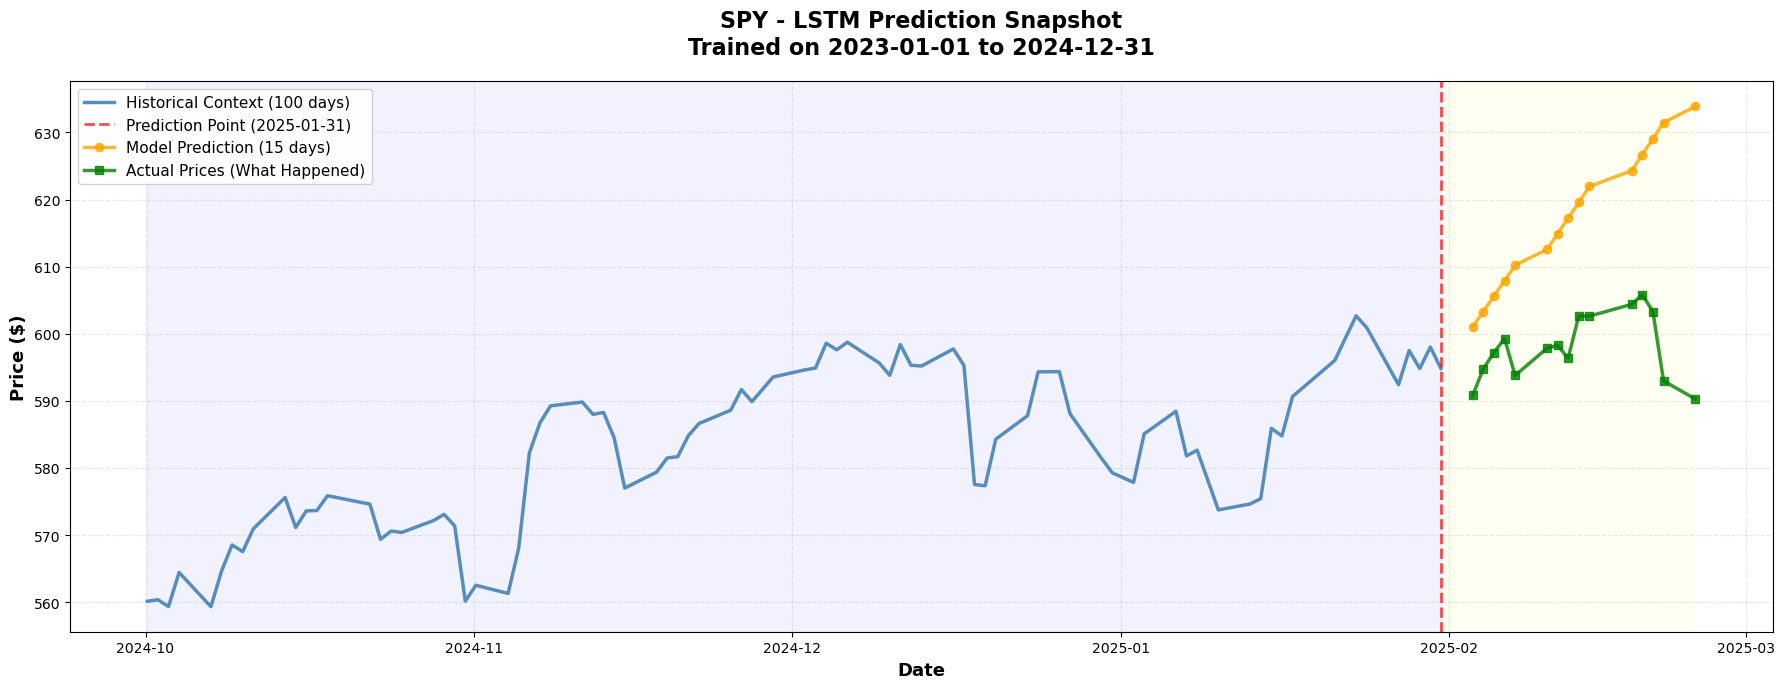


VISUALIZATION BREAKDOWN
Blue line: Historical context (what model saw)
Red line: Prediction moment
Orange line: What model predicted would happen
Green line: What actually happened


In [10]:
# Create the main visualization
fig, ax = plt.subplots(figsize=(18, 7))

# Plot 1: Historical context (100 days leading up to prediction)
ax.plot(context_data.index, context_data['Close'], 
        linewidth=2.5, color='steelblue', label='Historical Context (100 days)', alpha=0.9)

# Plot 2: Prediction point (vertical line)
ax.axvline(x=prediction_date, color='red', linestyle='--', linewidth=2, 
          label=f'Prediction Point ({prediction_date.date()})', alpha=0.7)

# Plot 3: Model's prediction (next 15 days)
ax.plot(actual_future_dates, predicted_prices,
        linewidth=2.5, color='orange', marker='o', markersize=6,
        label=f'Model Prediction ({PREDICTION_HORIZON} days)', alpha=0.8)

# Plot 4: Actual prices that occurred (overlay)
ax.plot(actual_future_dates, actual_future_prices,
        linewidth=2.5, color='green', marker='s', markersize=6,
        label='Actual Prices (What Happened)', alpha=0.8)

# Styling
ax.set_title(f'{SYMBOL} - LSTM Prediction Snapshot\nTrained on {TRAIN_START} to {TRAIN_END}', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# Add shaded regions for clarity
ax.axvspan(context_data.index[0], prediction_date, alpha=0.05, color='blue', label='_nolegend_')
ax.axvspan(prediction_date, actual_future_dates[-1], alpha=0.05, color='yellow', label='_nolegend_')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("VISUALIZATION BREAKDOWN")
print(f"{'='*60}")
print(f"Blue line: Historical context (what model saw)")
print(f"Red line: Prediction moment")
print(f"Orange line: What model predicted would happen")
print(f"Green line: What actually happened")
print(f"{'='*60}")

## 9. Detailed Comparison: Predicted vs Actual

In [11]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Date': actual_future_dates,
    'Predicted': predicted_prices,
    'Actual': actual_future_prices,
    'Error ($)': np.array(predicted_prices) - actual_future_prices,
    'Error (%)': ((np.array(predicted_prices) - actual_future_prices) / actual_future_prices) * 100
})

comparison_df['Day'] = [f'+{i}' for i in range(1, len(comparison_df) + 1)]
comparison_df = comparison_df[['Day', 'Date', 'Predicted', 'Actual', 'Error ($)', 'Error (%)']]

print(f"\n{'='*80}")
print(f"PREDICTION vs ACTUAL - Day by Day Breakdown")
print(f"{'='*80}")
print(comparison_df.to_string(index=False))
print(f"{'='*80}")

# Summary statistics
mae = np.mean(np.abs(comparison_df['Error ($)']))
rmse = np.sqrt(np.mean(comparison_df['Error ($)'] ** 2))
mape = np.mean(np.abs(comparison_df['Error (%)']))

print(f"\nSummary Statistics:")
print(f"  Mean Absolute Error (MAE): ${mae:.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


PREDICTION vs ACTUAL - Day by Day Breakdown
Day                      Date  Predicted     Actual  Error ($)  Error (%)
 +1 2025-02-03 05:00:00+00:00 601.023376 590.831726  10.191650   1.724967
 +2 2025-02-04 05:00:00+00:00 603.314819 594.795166   8.519653   1.432368
 +3 2025-02-05 05:00:00+00:00 605.613098 597.206848   8.406250   1.407594
 +4 2025-02-06 05:00:00+00:00 607.920166 599.282593   8.637573   1.441319
 +5 2025-02-07 05:00:00+00:00 610.235962 593.796997  16.438965   2.768449
 +6 2025-02-10 05:00:00+00:00 612.560608 597.829590  14.731018   2.464083
 +7 2025-02-11 05:00:00+00:00 614.894104 598.284302  16.609802   2.776239
 +8 2025-02-12 05:00:00+00:00 617.236511 596.356812  20.879700   3.501209
 +9 2025-02-13 05:00:00+00:00 619.587830 602.652893  16.934937   2.810065
+10 2025-02-14 05:00:00+00:00 621.948120 602.623291  19.324829   3.206784
+11 2025-02-18 05:00:00+00:00 624.317383 604.392456  19.924927   3.296687
+12 2025-02-19 05:00:00+00:00 626.695679 605.815857  20.879822   3.

## 10. Directional Accuracy Check

In [12]:
# Check if model predicted UP/DOWN correctly for each day
base_price = single_prediction['actual_price']

# Predicted directions (up or down from base price)
pred_directions = np.sign(np.array(predicted_prices) - base_price)
actual_directions = np.sign(actual_future_prices - base_price)

correct_directions = pred_directions == actual_directions
directional_accuracy = np.mean(correct_directions) * 100

print(f"\n{'='*60}")
print("DIRECTIONAL ACCURACY")
print(f"{'='*60}")
print(f"Did model predict UP/DOWN correctly?\n")

for i, (date, pred_dir, actual_dir, correct) in enumerate(zip(actual_future_dates, pred_directions, actual_directions, correct_directions)):
    pred_str = "UP ↑" if pred_dir > 0 else "DOWN ↓" if pred_dir < 0 else "FLAT →"
    actual_str = "UP ↑" if actual_dir > 0 else "DOWN ↓" if actual_dir < 0 else "FLAT →"
    status = "✓" if correct else "✗"
    print(f"  Day +{i+1} ({date.date()}): Predicted {pred_str:8} | Actual {actual_str:8} | {status}")

print(f"\nOverall Directional Accuracy: {directional_accuracy:.1f}%")
print(f"Correct: {np.sum(correct_directions)}/{len(correct_directions)} days")
print(f"{'='*60}")


DIRECTIONAL ACCURACY
Did model predict UP/DOWN correctly?

  Day +1 (2025-02-03): Predicted UP ↑     | Actual DOWN ↓   | ✗
  Day +2 (2025-02-04): Predicted UP ↑     | Actual DOWN ↓   | ✗
  Day +3 (2025-02-05): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +4 (2025-02-06): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +5 (2025-02-07): Predicted UP ↑     | Actual DOWN ↓   | ✗
  Day +6 (2025-02-10): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +7 (2025-02-11): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +8 (2025-02-12): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +9 (2025-02-13): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +10 (2025-02-14): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +11 (2025-02-18): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +12 (2025-02-19): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +13 (2025-02-20): Predicted UP ↑     | Actual UP ↑     | ✓
  Day +14 (2025-02-21): Predicted UP ↑     | Actual DOWN ↓   | ✗
  Day +15 (2025-02-24): Predicted UP ↑ 

## 11. Hit Rate Analysis (Tolerance-Based)

In [13]:
# Calculate hit rates at different tolerance levels
tolerances = [0.001, 0.005, 0.01, 0.02, 0.05]  # 0.1%, 0.5%, 1%, 2%, 5%

print(f"\n{'='*60}")
print("HIT RATE ANALYSIS (Tolerance-Based)")
print(f"{'='*60}")
print("How often was the prediction 'close enough'?\n")

for tolerance in tolerances:
    pct_errors = np.abs((np.array(predicted_prices) - actual_future_prices) / actual_future_prices)
    hits = pct_errors <= tolerance
    hit_rate = np.mean(hits) * 100
    hit_count = np.sum(hits)
    
    tolerance_pct = tolerance * 100
    print(f"  ±{tolerance_pct:.1f}% tolerance: {hit_rate:.1f}% hit rate ({hit_count}/{len(hits)} days)")

print(f"{'='*60}")


HIT RATE ANALYSIS (Tolerance-Based)
How often was the prediction 'close enough'?

  ±0.1% tolerance: 0.0% hit rate (0/15 days)
  ±0.5% tolerance: 0.0% hit rate (0/15 days)
  ±1.0% tolerance: 0.0% hit rate (0/15 days)
  ±2.0% tolerance: 26.7% hit rate (4/15 days)
  ±5.0% tolerance: 86.7% hit rate (13/15 days)


## 12. Summary Report

In [14]:
print(f"\n\n{'#'*80}")
print(f"#{'LSTM PREDICTION SNAPSHOT - FINAL REPORT':^78}#")
print(f"{'#'*80}\n")

print(f"Symbol: {SYMBOL}")
print(f"Prediction Date: {prediction_date.date()}")
print(f"Forecast Horizon: {PREDICTION_HORIZON} days\n")

print(f"Model Training:")
print(f"  Period: {TRAIN_START} to {TRAIN_END}")
print(f"  Lookback Window: {LOOKBACK_WINDOW} days")
print(f"  Architecture: {NUM_LAYERS} LSTM layers, {LSTM_UNITS} units each")
print(f"  Mode: {PREDICTION_MODE}\n")

print(f"Performance Metrics:")
print(f"  MAE: ${mae:.2f}")
print(f"  RMSE: ${rmse:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  Directional Accuracy: {directional_accuracy:.1f}%\n")

print(f"Key Insight:")
if directional_accuracy > 60:
    print(f"  ✓ Model shows GOOD directional prediction ability (>{directional_accuracy:.0f}%)")
elif directional_accuracy > 50:
    print(f"  → Model shows MODERATE directional prediction (>{directional_accuracy:.0f}%)")
else:
    print(f"  ✗ Model struggles with direction (<50%), needs improvement")

if mape < 1:
    print(f"  ✓ Excellent price accuracy (MAPE < 1%)")
elif mape < 2:
    print(f"  ✓ Good price accuracy (MAPE < 2%)")
else:
    print(f"  → Moderate price accuracy (MAPE {mape:.1f}%)")

print(f"\n{'#'*80}")



################################################################################
#                   LSTM PREDICTION SNAPSHOT - FINAL REPORT                    #
################################################################################

Symbol: SPY
Prediction Date: 2025-01-31
Forecast Horizon: 15 days

Model Training:
  Period: 2023-01-01 to 2024-12-31
  Lookback Window: 100 days
  Architecture: 2 LSTM layers, 50 units each
  Mode: recursive

Performance Metrics:
  MAE: $19.29
  RMSE: $21.70
  MAPE: 3.23%
  Directional Accuracy: 66.7%

Key Insight:
  ✓ Model shows GOOD directional prediction ability (>67%)
  → Moderate price accuracy (MAPE 3.2%)

################################################################################


---
## Next Steps

**To try different prediction dates:**
- Change `PREDICTION_DATE` in cell 4
- Re-run from cell 5 onwards (no need to retrain)

**To match your friend's exact setup:**
- Set `LOOKBACK_WINDOW = 500`
- Change to `TIMEFRAME_UNIT = "Minute"`, `MULTIPLIER = 5`
- Retrain model

**To test other symbols:**
- Change `SYMBOL` (e.g., "NVDA", "AAPL", "QQQ")
- Retrain model with new data